# Final Project

### Section 1
**(i)**
In this supply chain graph, each node represents either a supplier company or an automaker's production region, and each directed edge represents a supply relationship in which a supplier provides a specific component to an OEM. The edges carry attributes such as the component category (“Label”), which identifies whether the supplier provides batteries, motors, power electronics, autonomous-driving components, or other systems; and geographic information (“region,” later parsed into source_region → market_region), which indicates the flow of components across countries or regions. The graph includes a weight attribute, which indicates how many different products a supplier provides to the demand side. For example, if a supplier provides batteries and motors to an automaker, its weight is 2. Because suppliers only connect to automakers and not to other suppliers, and automakers do not connect to each other, the network naturally forms a bipartite graph. It is also a multi-edge graph, since a single supplier-OEM pair can appear multiple times, each corresponding to a different component category, and these parallel edges capture the diversity of technologies supplied within the same relationship. Thus, the graph is best described as a directed, bipartite, multi-edge network.

**(ii)**
Regarding the data, I collect the data myself. Since I haven't found a single authoritative website that includes all supply relationships, I can only fill out my forms through company announcements or business introductions.

**(iii)**
My network is only a sub-sample of a latent network. The supply relationships in the entire trolley market are extremely complex, and I cannot consider the trolley supply sources for every country. Therefore, I only considered the overall trolley supply markets of China, the United States, and Europe. Furthermore, there are too many vehicle components, and I cannot obtain enough information to show the supply sources of every component for every brand of trolley in every region. Therefore, I only collected data from 15 world-renowned trolley brands for presentation. This selection does indeed lead to many biases, including but not limited to the possibility that different suppliers may exist for different models within the same region. Multiple component suppliers in the same region may produce vehicles at different times.

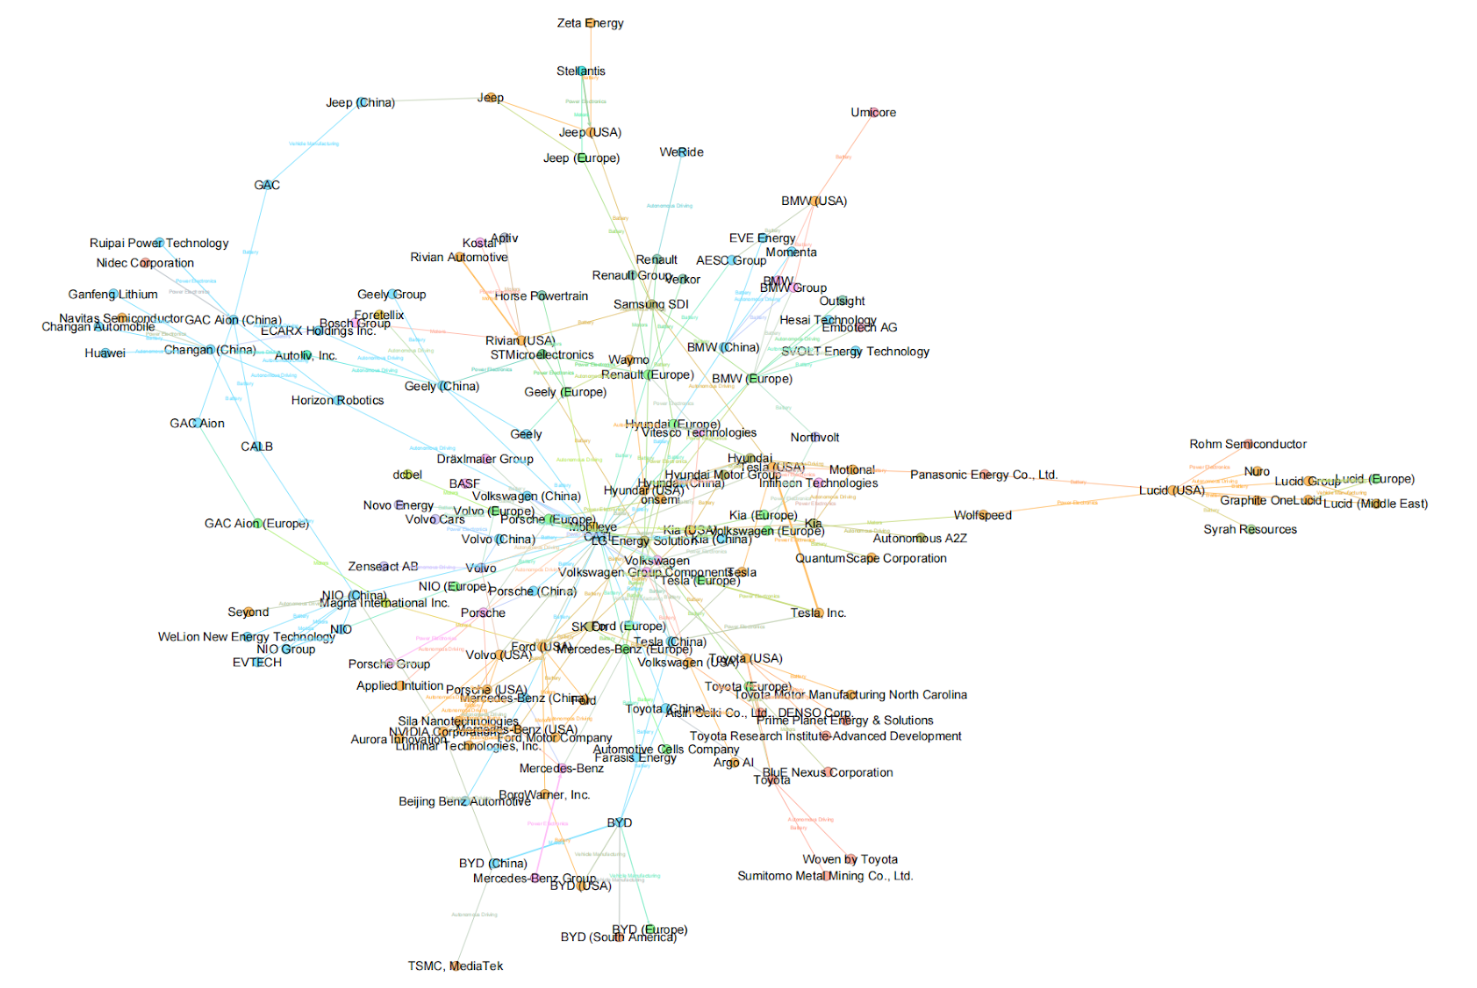


### Section 2


In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.figsize": (4, 3),    
    "figure.dpi": 200,            
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

def publication_hist(data, bins, xlabel, ylabel, title, filename=None):
    fig, ax = plt.subplots()
    ax.hist(data,
            bins=bins,
            edgecolor="black",
            linewidth=0.6)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    if filename is not None:
        fig.savefig(filename, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)


file_path = "EV_supply_graph.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

edges = df[["Source", "Target", "Weight"]].copy()

G = nx.DiGraph()
for _, row in edges.iterrows():
    src = row["Source"]
    tgt = row["Target"]
    w   = row["Weight"]

    if G.has_edge(src, tgt):
        G[src][tgt]["weight"] += w
    else:
        G.add_edge(src, tgt, weight=w)

G_undirected = G.to_undirected()

n = len(G.nodes())

Degree distribution is a good choice for showcasing the characteristics of a chart. In my chart, the out-degree quantity shows who supplies to how many people, while the in-degree distribution shows who gets supplies from how many people.

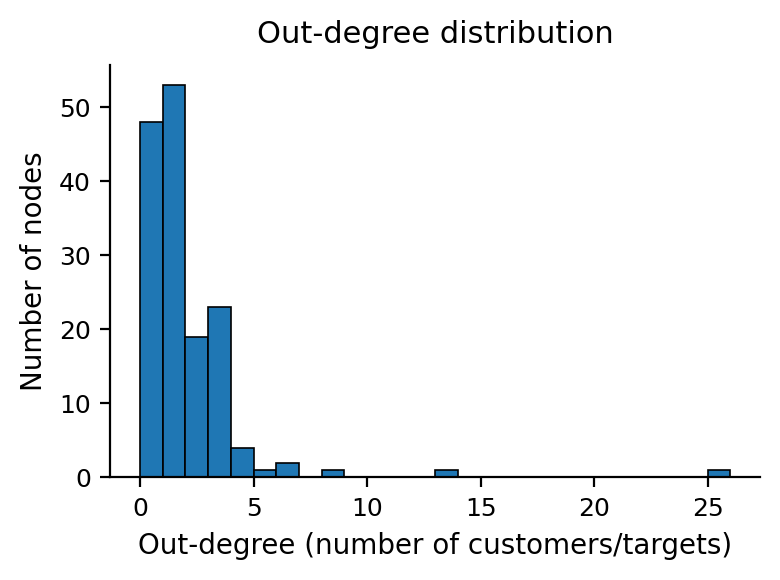

In [2]:
out_degrees = dict(G.out_degree())
in_degrees  = dict(G.in_degree())

out_vals = list(out_degrees.values())
in_vals  = list(in_degrees.values())

if len(out_vals) > 0:
    out_max = max(out_vals)
    out_bins = range(0, out_max + 2)
    publication_hist(out_vals,
                     bins=out_bins,
                     xlabel="Out-degree (number of customers/targets)",
                     ylabel="Number of nodes",
                     title="Out-degree distribution",
                     filename="degree_out_distribution.png")

**(i)**
The out-degree chart reveals that the vast majority of suppliers have very low out-degrees, while a very small number have extremely high out-degrees. This is a typical heavy-tailed distribution. Furthermore, the chart shows that most suppliers serve only a small number of customers, indicating a very broad supply chain ecosystem but low overall concentration.

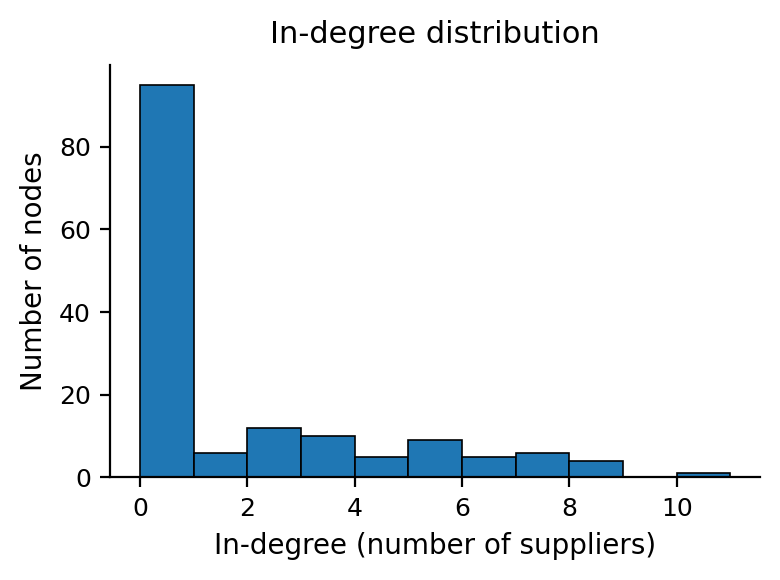

In [3]:
if len(in_vals) > 0:
    in_max = max(in_vals)
    in_bins = range(0, in_max + 2)
    publication_hist(in_vals,
                     bins=in_bins,
                     xlabel="In-degree (number of suppliers)",
                     ylabel="Number of nodes",
                     title="In-degree distribution",
                     filename="degree_in_distribution.png")

**(ii)** The in-degree distribution exhibits a different pattern, with a more even distribution ranging from 2 to 8. Most nodes have an in-degree between 2 and 6, indicating that automakers do not rely on a single supplier but maintain a diversified supply chain. Because multiple suppliers coexist, a single supplier's disruption will not immediately lead to failure.

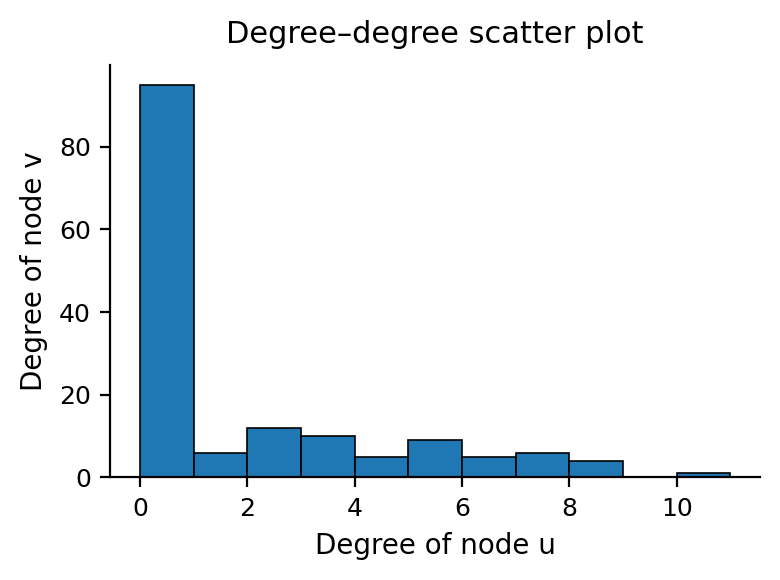

In [4]:
deg_dict = dict(G.degree())

x_vals = []
y_vals = []

for u, v in G.edges():
    x_vals.append(deg_dict[u])
    y_vals.append(deg_dict[v])
    
publication_hist(in_vals,
                     bins=in_bins,
                     xlabel="Degree of node u",
                     ylabel="Degree of node v",
                     title="Degree–degree scatter plot",
                     filename="assortativity_deg_deg_scatter.png")


**(iii)** This degree-degree scatter plot shows the degree combinations of the nodes at both ends of each edge, reflecting whether a homogenous structure exists in the network where "high-degree nodes are interconnected." The vast majority of points are concentrated in the lower left corner, indicating that many connections occur between low-degree nodes and high-degree nodes, while there are almost no interconnections between high-degree nodes themselves. Meanwhile, only a few isolated points appear on the right, corresponding to suppliers with extremely high degrees, primarily connecting to downstream nodes with very low degrees, rather than other large nodes. This structure clearly reveals a disassortative mixing in the network: core suppliers act as hubs, forming radial connections with a large number of peripheral nodes, rather than forming an interconnected core cluster. This pattern is typical of supply chain networks, implying that the importance of upstream key nodes is extremely high, and their failure will have a disproportionate systemic impact on the overall network.

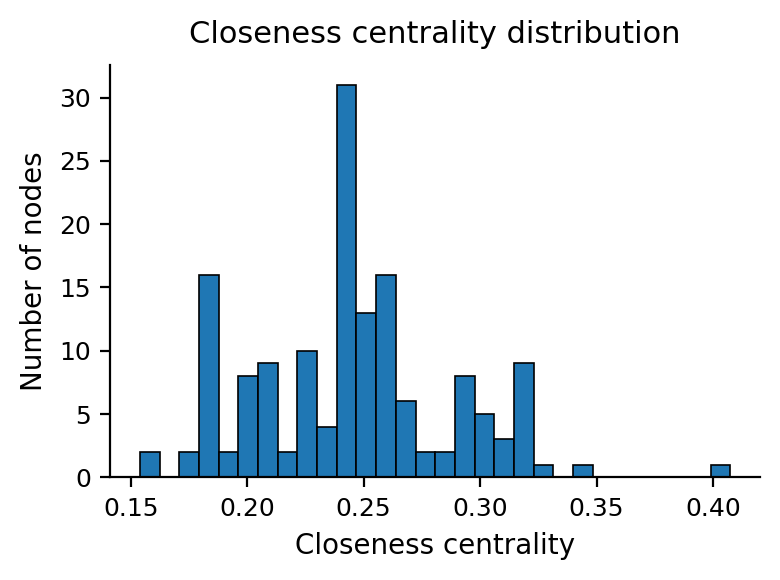

In [5]:
clo_cen = nx.closeness_centrality(G_undirected)
clo_vals = list(clo_cen.values())

publication_hist(clo_vals,
                 bins=30,
                 xlabel="Closeness centrality",
                 ylabel="Number of nodes",
                 title="Closeness centrality distribution",
                 filename="centrality_closeness_distribution.png")

**(iiii)** Several key characteristics can be observed from the graph. The proximity centrality of most nodes is concentrated in the 0.20–0.28 range, indicating that the overall supply chain network exhibits a moderately connected structure. Most companies are neither extremely central nodes nor completely peripheral nodes. A significant peak exists in the middle of the distribution (especially in the 0.24–0.26 range), representing a large number of suppliers at a "medium distance" level from automakers in the supply chain. These include medium-sized suppliers that provide to multiple automakers but have a relatively limited coverage area. A small number of nodes on the right side of the distribution reach 0.30–0.40; these are the most central nodes in the network. A few nodes appear on the left side in the 0.15–0.18 range, indicating that some nodes are relatively distant from the rest of the network. These include small suppliers that only supply a few automakers, or regional nodes located in specific markets; their structural role in the overall supply network is relatively weak.

Overall, this distribution shows that the supply chain network is neither highly centralized nor completely decentralized, but rather exhibits a multi-tiered structure: a few core suppliers or major market nodes form the connecting backbone, medium-sized supply chain enterprises form the middle layer, and a large number of small or local nodes constitute the outer layer. This structure not only explains the source of the industry's supply chain stability but also reveals potential vulnerabilities—especially the few highly central nodes on the right side of the distribution, whose disruptions will quickly ripple through the entire network.

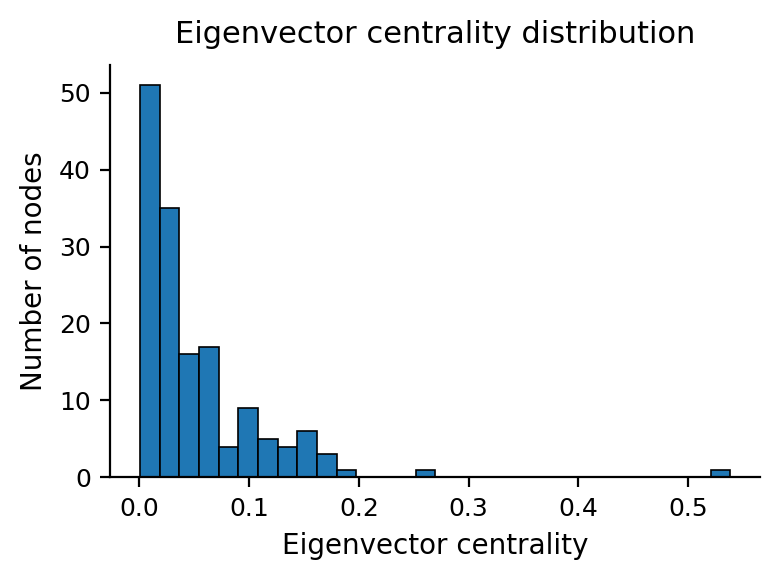

In [6]:
eig_cen = nx.eigenvector_centrality(G_undirected, max_iter=2000)
eig_vals = list(eig_cen.values())

publication_hist(eig_vals,
                 bins=30,
                 xlabel="Eigenvector centrality",
                 ylabel="Number of nodes",
                 title="Eigenvector centrality distribution",
                 filename="centrality_eigenvector_distribution.png")

**(v)** Through Eigenvector Centrality analysis, we found that most nodes are clustered in the 0-0.05 range, indicating that most suppliers only serve a few target automakers. These nodes mostly belong to the outer layer of the supply chain and have limited impact on the overall information and resource flow. However, a very small number of highly central nodes exist on the right side, indicating the existence of super-core nodes in the supply chain. Their centrality is significantly higher than other nodes, indicating that they are located at the intersection of important supply chain paths. The overall distribution exhibits a right-skewed structure, reflecting the significant differences in supply chain scale. The vast majority of enterprises are at the edge of the network.

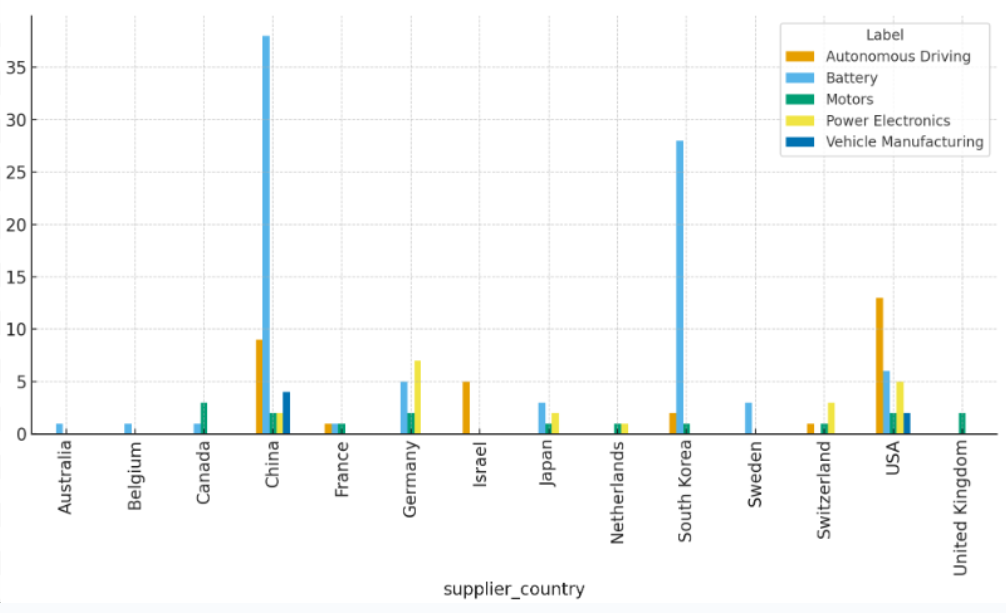

**(ex)** The chart here breaks down five key component categories—batteries, motors, power electronics, autonomous driving systems, and vehicle manufacturing—and shows how many suppliers in each country provide each type of component.This visualization helps us understand not only which countries participate in the EV supply chain, but also what role each country tends to play.First, China and South Korea clearly dominate battery supply.
China has the broadest supplier base overall, with large numbers of suppliers across multiple categories, but its battery bar towers above others. South Korea, despite having fewer categories overall, has extremely high battery specialization.
This confirms what we already know from industry insights: both countries are global hubs for battery production, driven by companies such as CATL, BYD, and LG Energy Solution.Second, the United States displays a more balanced profile, with meaningful contributions in autonomous driving, power electronics, and vehicle manufacturing.
The U.S. has fewer battery suppliers compared to East Asia, but it is stronger in software-related and advanced electronics components, reflecting its technological ecosystem.
Third, Japan and Germany show diversified but moderate participation.
Japan contributes across motors, electronics, and some battery suppliers, while Germany shows steady involvement in motors and power electronics. These patterns align with their established automotive industries, which retain strengths in drivetrain and electronics engineering.

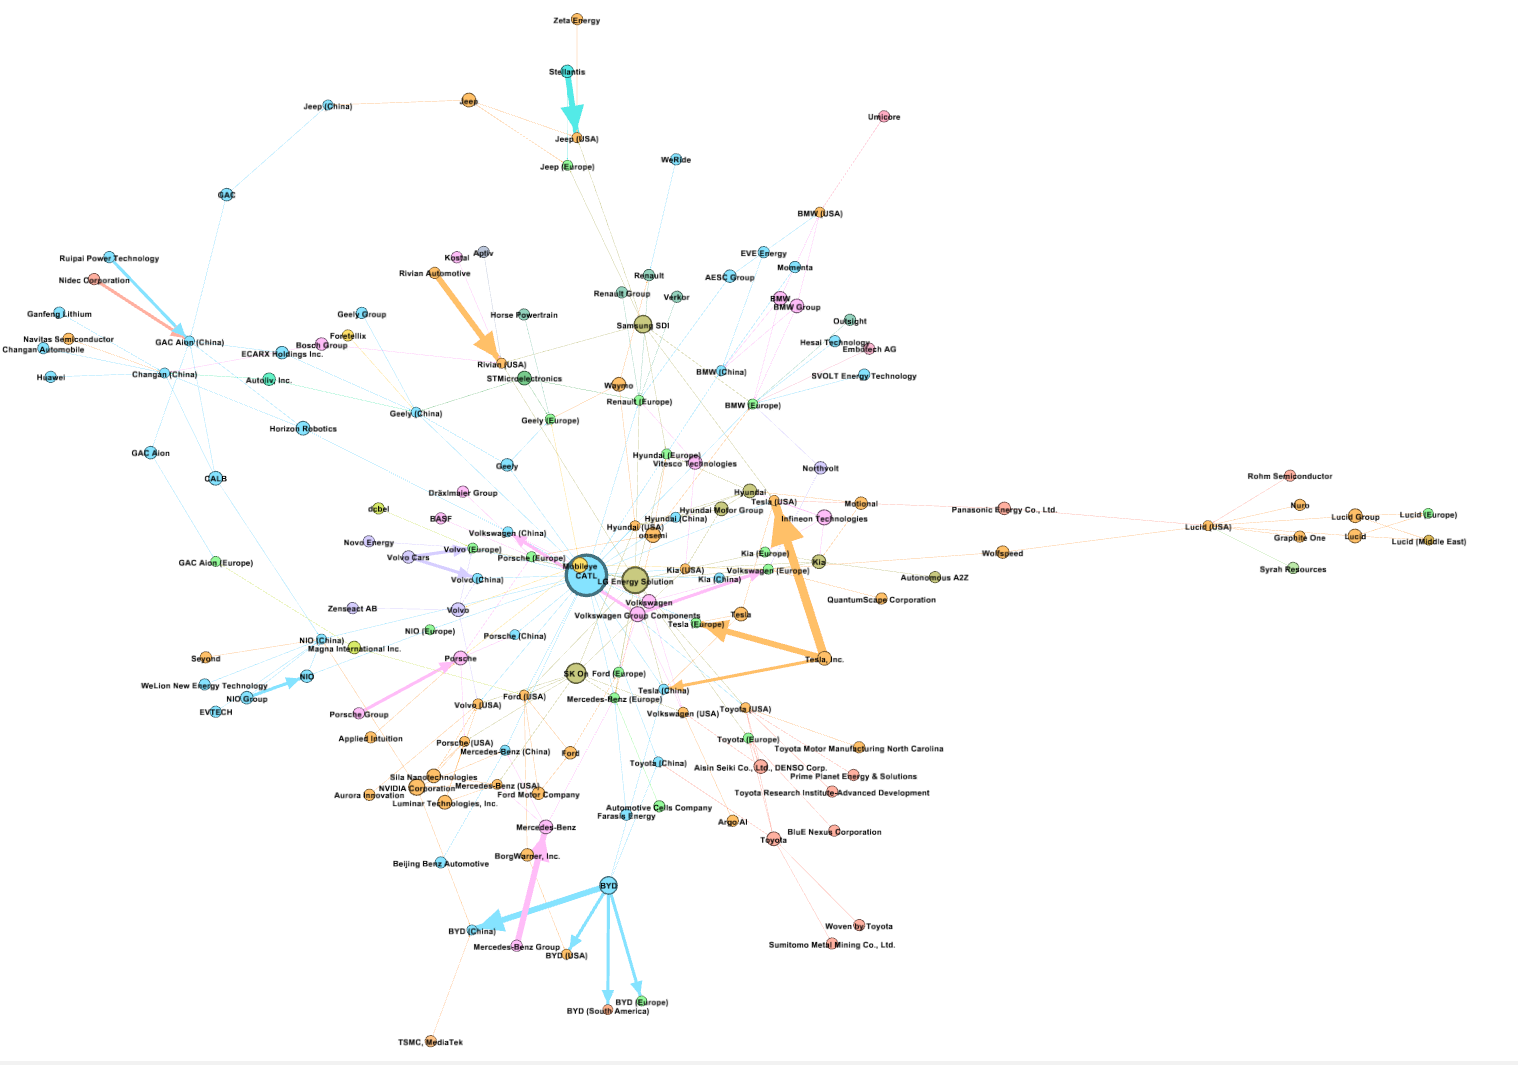

**(iv)** By using out-degree measurement to determine node size, we can obtain the above diagram. CATL and LG, as the largest suppliers, possess the largest node sizes. This demonstrates their crucial role in the entire tram supply chain.

## Section 3

In [7]:
import networkx as nx
import numpy as np
import random

def generate_directed_null_graphs_stable(G, num_null=1000):
    """
This function generates a set of stable directed null networks based on a directed configuration model.

The function will:
1. Read the in-degree and out-degree of each node in the original network G;
2. Randomly generate a multi-directed graph satisfying the same degree sequence using the directed_configuration_model;
3. Convert the multi-directed graph into a simple directed graph: remove self-loops and merge multi-edges;
4. Remap the generated node indices back to the original node labels;
5. If the generated graph is isomorphic to the original network, skip the null graph (to avoid meaningless duplication);
6. Return a list of all generated null networks.

This null model keeps the in-degree and out-degree of each node completely unchanged, rearranging the connection structure only within permissible limits.
Therefore, it is suitable for examining which network features cannot be explained solely by the degree sequence.
"""
    nodes = list(G.nodes())
    n = len(nodes)
    in_deg = [G.in_degree(n) for n in nodes]
    out_deg = [G.out_degree(n) for n in nodes]

    null_graphs = []

    for _ in range(num_null):
        G_multi = nx.directed_configuration_model(in_deg, out_deg, create_using=nx.MultiDiGraph())
        index_to_node = {i: nodes[i] for i in range(n)}
        edges = set()
        for u, v in G_multi.edges():
            u_lab = index_to_node[u]
            v_lab = index_to_node[v]
            if u_lab == v_lab:
                continue
            edges.add((u_lab, v_lab))

        G_simple = nx.DiGraph()
        G_simple.add_nodes_from(nodes)
        G_simple.add_edges_from(edges)

        if nx.is_isomorphic(G_simple, G):
            continue

        null_graphs.append(G_simple)

    return null_graphs


In [8]:
null_graphs = generate_directed_null_graphs_stable(G, num_null=2000)

In [9]:
# some useful function
def compute_cdf(values):
    
    values = np.array(values)
    x_sorted = np.sort(values)
    n = len(values)
    cdf = np.arange(1, n+1) / n
    return x_sorted, cdf

def compute_average_ecdf(null_value_lists):
    all_values = np.concatenate([np.asarray(v) for v in null_value_lists])
    x_values = np.sort(np.unique(all_values))

    ecdf_list = []
    for values in null_value_lists:
        data = np.asarray(values)
        cdf_vals = np.array([(data <= x).mean() for x in x_values])
        ecdf_list.append(cdf_vals)

    ecdf_matrix = np.vstack(ecdf_list)
    average_ecdf = ecdf_matrix.mean(axis=0)

    return x_values, average_ecdf

    
def get_graph_values(G, statistic):
    """
Extracts a numerical array from graph G based on the specified network feature name.

Supported features include:
- "in_degree": In-degree of each node;
- "out_degree": Out-degree of each node;
- "degree": Undirectedness (in-degree + out-degree for directed graphs);
- "closeness": Closeness centrality of nodes;
- "eigenvector": Eigenvector centrality of nodes (converts the graph to undirected to ensure stable definition);
- "Clustering": Clustering coefficients of nodes (converts directed graphs to undirected as well).

The function returns a NumPy array, which can be used to plot distributions, calculate CDF/ECDF, or perform statistical analysis.
A ValueError will be raised if the input statistic is not supported.
"""
    if statistic == "in_degree":
        vals = np.array([d for _, d in G.in_degree()])
    elif statistic == "out_degree":
        vals = np.array([d for _, d in G.out_degree()])
    elif statistic == "closeness":
        vals = np.array(list(nx.closeness_centrality(G).values()))
    elif statistic == "eigenvector":
        # convert to undirected so eigenvector centrality is well-defined
        G_u = G.to_undirected()
        vals = np.array(list(nx.eigenvector_centrality_numpy(G_u).values()))
    elif statistic == "Clustering":
        if isinstance(G, nx.DiGraph):
            G_u = G.to_undirected()
        else:
            G_u = G
        vals = np.array(list(nx.clustering(G_u).values()))
    elif statistic == "degree":
        vals = np.array([d for _, d in G.degree()])
    else:
        raise ValueError(f"Unsupported statistic: {statistic}")
    return vals

In [10]:
def plot_G_vs_null_cdf(G, null_graphs, statistic, ax=None):
    """
This function plots the distribution of the original network and a set of null networks on a specific network feature.

This function will:
1. Calculate the CDF of the original network for a specified feature (e.g., in-degree, out-degree, closeness, eigenvector);
2. Calculate the average ECDF of all null networks on the same feature;
3. Plot the two distribution curves on the same graph to visually demonstrate whether the original network significantly deviates from the null model.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

    G_vals = get_graph_values(G, statistic)
    x_G, cdf_G = compute_cdf(G_vals)

    null_value_lists = [get_graph_values(g_null, statistic) for g_null in null_graphs]
    x_null, avg_ecdf = compute_average_ecdf(null_value_lists)

    ax.plot(
        x_G,
        cdf_G,
        label="Original network (CDF)",
        linewidth=2.0,
        color="black"
    )
    ax.plot(
        x_null,
        avg_ecdf,
        label="Null models (average ECDF)",
        linestyle="--",
        linewidth=2.0,
        color="tab:blue"
    )

    if statistic == "in_degree":
        xlabel = "In-degree"
    elif statistic == "out_degree":
        xlabel = "Out-degree"
    elif statistic == "closeness":
        xlabel = "Closeness centrality"
    elif statistic == "eigenvector":
        xlabel = "Eigenvector centrality"
    else:
        xlabel = statistic

    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Cumulative distribution", fontsize=12)
    ax.legend(fontsize=10, frameon=False, loc="lower right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.4)
    ax.margins(x=0.02, y=0.02)

    return ax

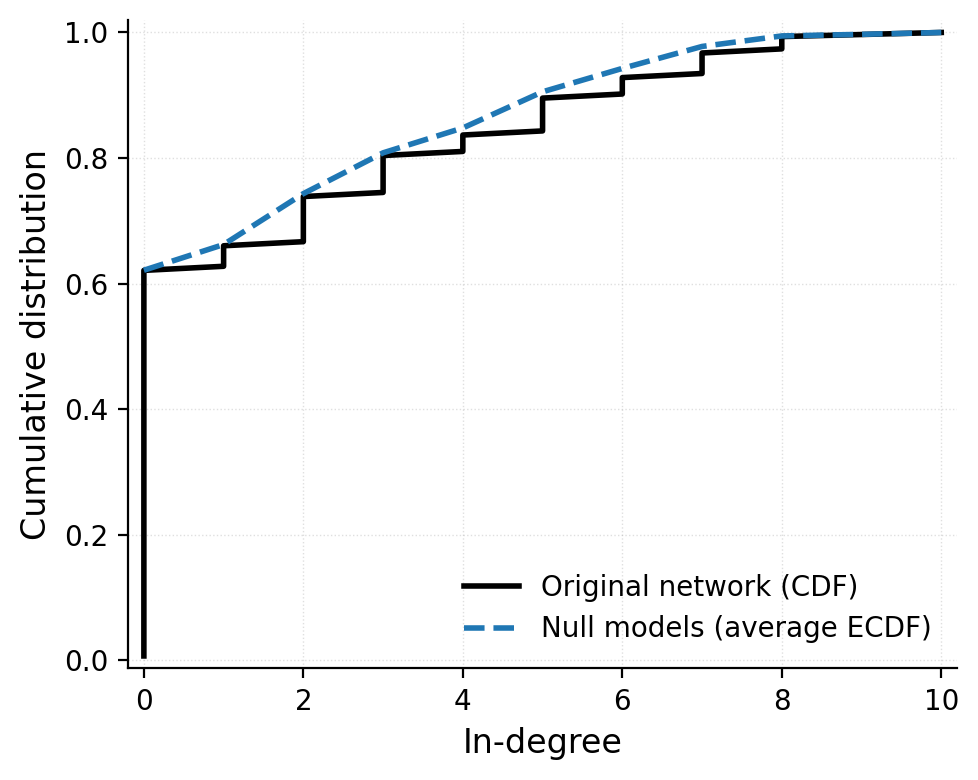

In [11]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, null_graphs, statistic="in_degree", ax=ax)
fig.tight_layout()

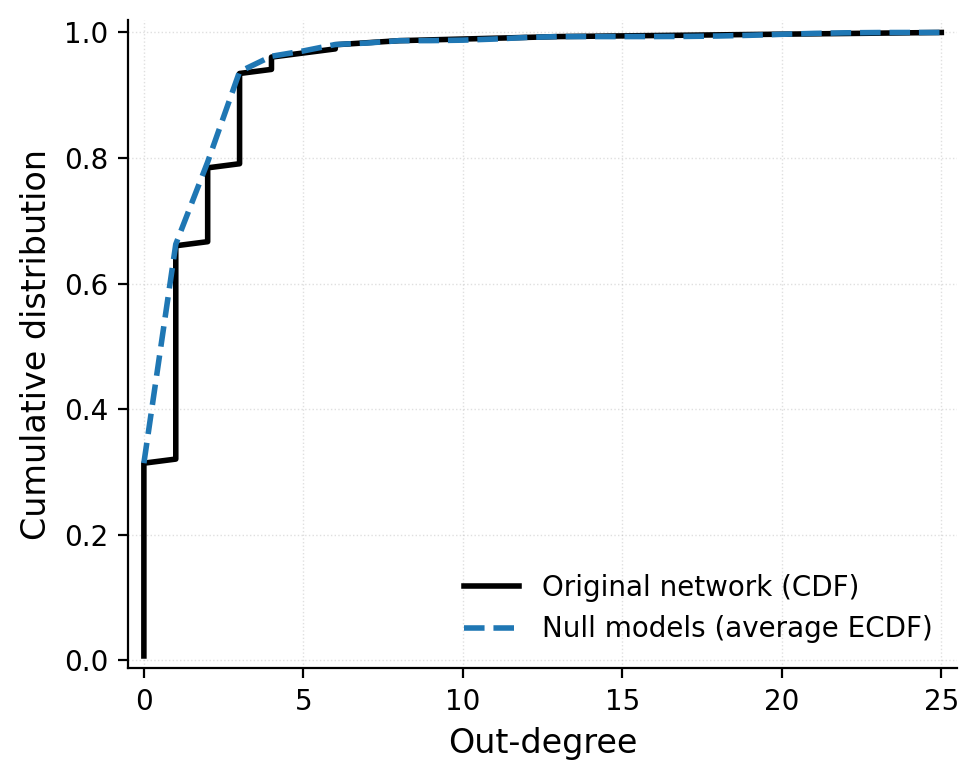

In [12]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, null_graphs, statistic="out_degree", ax=ax)
fig.tight_layout()

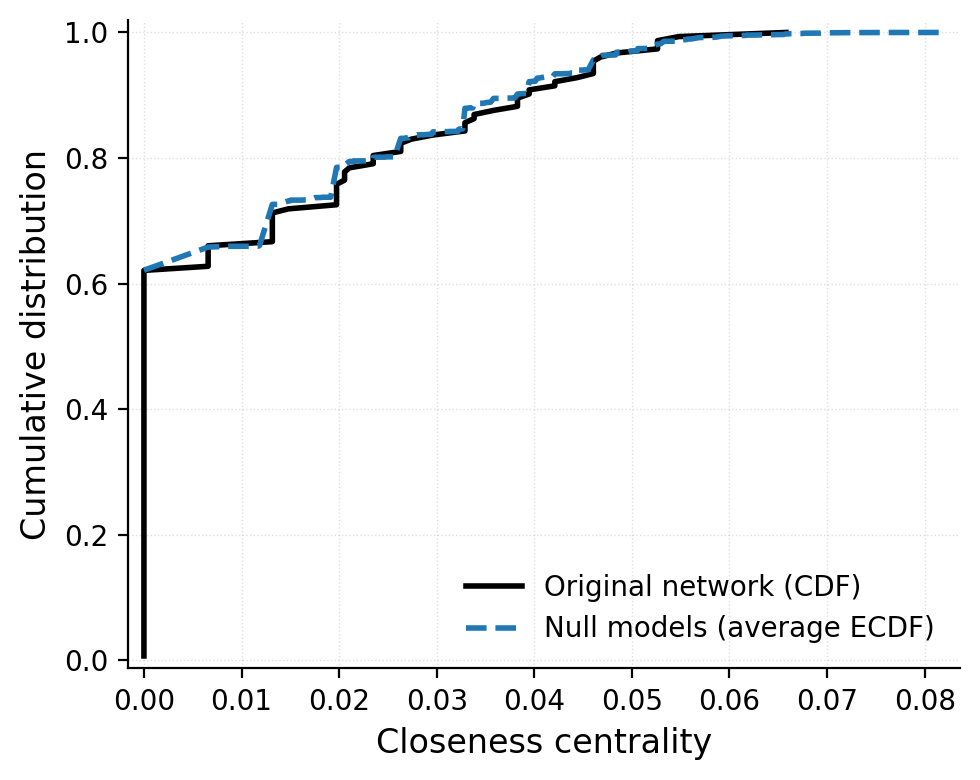

In [13]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, null_graphs, statistic="closeness", ax=ax)
fig.tight_layout()

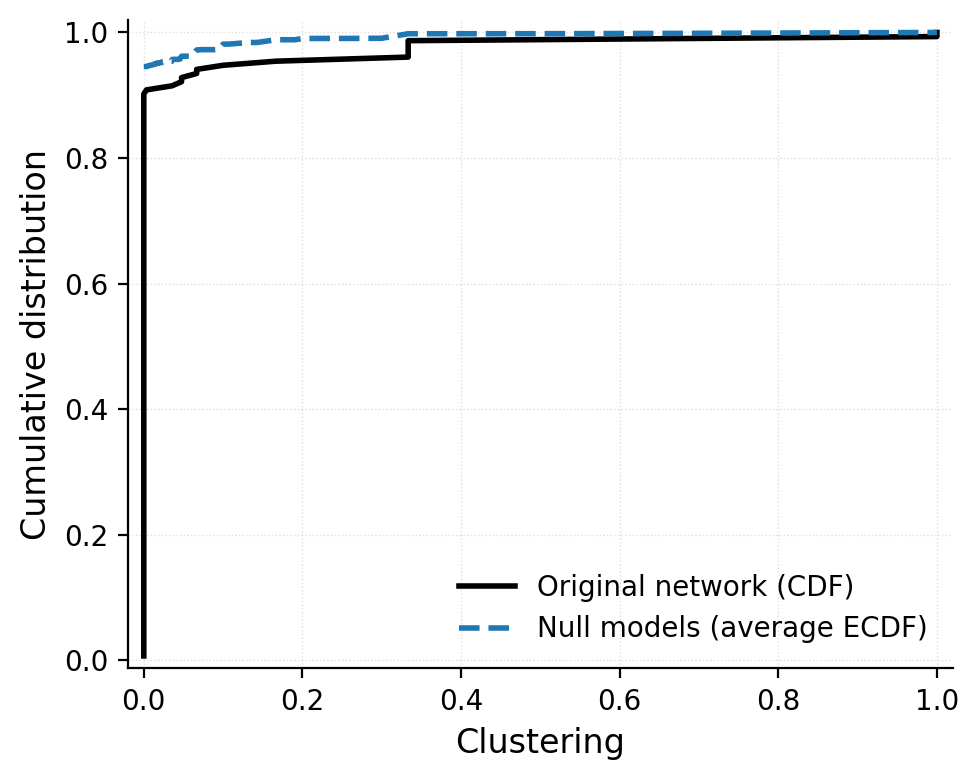

In [14]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, null_graphs, statistic="Clustering", ax=ax)
fig.tight_layout()

In [15]:
from scipy.stats import ks_2samp

def ks_test_distribution(G, null_graphs, statistic):

    G_vals = get_graph_values(G, statistic)
    null_value_lists = [get_graph_values(g_null, statistic) for g_null in null_graphs]
    null_all = np.concatenate(null_value_lists)
    ks_stat, p_val = ks_2samp(G_vals, null_all)

    return ks_stat, p_val
    
statistics = ["in_degree", "out_degree", "closeness", "Clustering"]

for stat in statistics:
    ks_stat, p_val = ks_test_distribution(G, null_graphs, stat)
    print(f"{stat}: KS statistic = {ks_stat:.4f}, p-value = {p_val:.4g}")

in_degree: KS statistic = 0.0146, p-value = 1
out_degree: KS statistic = 0.0093, p-value = 1
closeness: KS statistic = 0.0270, p-value = 0.9998
Clustering: KS statistic = 0.0454, p-value = 0.8969


**(iii)** Because the degree-preserving model strictly maintains perfect consistency between the in-degree and out-degree of each node, the generated null network shows no difference in in-degree and out-degree distributions from the original network. When in-degree and out-degree are completely fixed, the overall reachability of the network and the probability of forming triangles are strongly constrained, making these distributions of the null network very close to those of the real network. In my EV supply chain network, the node degree distribution almost entirely determines its closeness and clustering, while the influence of other structural factors is very weak.

## Section 4

In [16]:
def generate_BA_null_graphs(G, num_null=200):
    null_graphs = []
    n = len(G.nodes())
    for i in range(num_null):
        G_simple = nx.barabasi_albert_graph(n, 1, seed = i)
        null_graphs.append(G_simple)

    return null_graphs
BA_graphs = generate_BA_null_graphs(G,num_null=200)

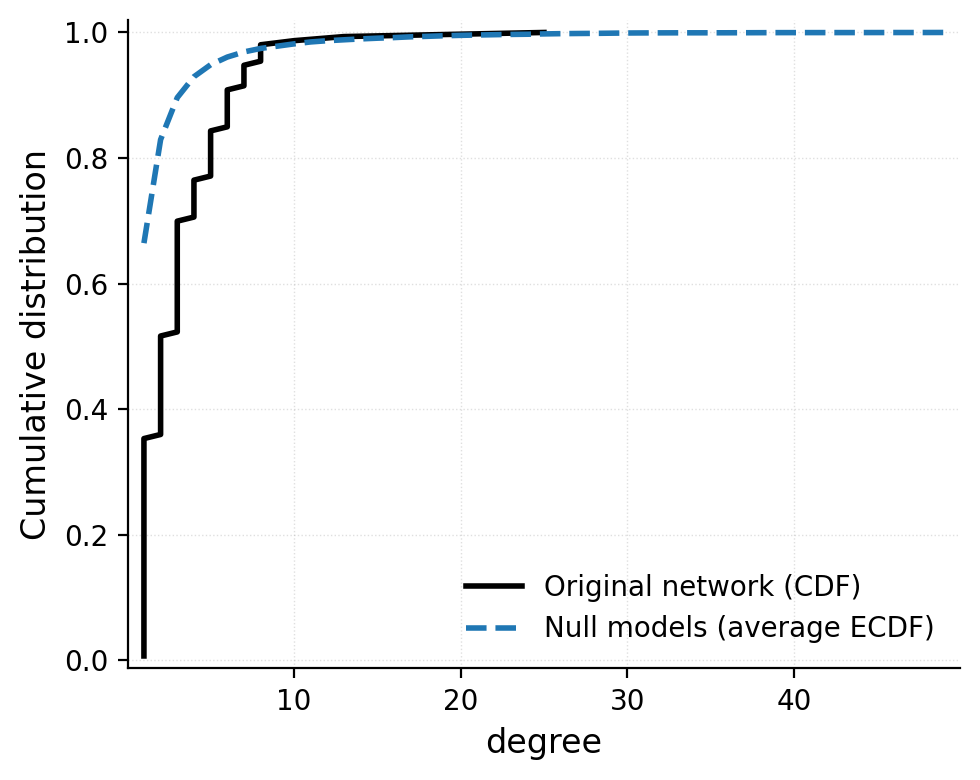

In [17]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, BA_graphs, statistic="degree", ax=ax)
fig.tight_layout()

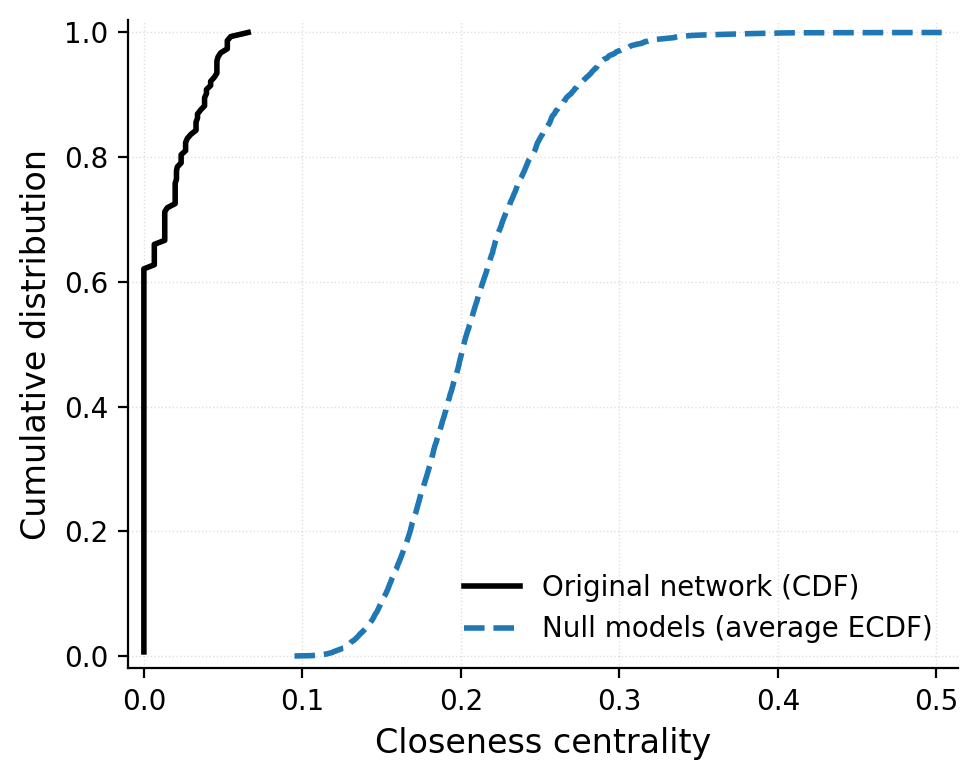

In [18]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, BA_graphs, statistic="closeness", ax=ax)
fig.tight_layout()

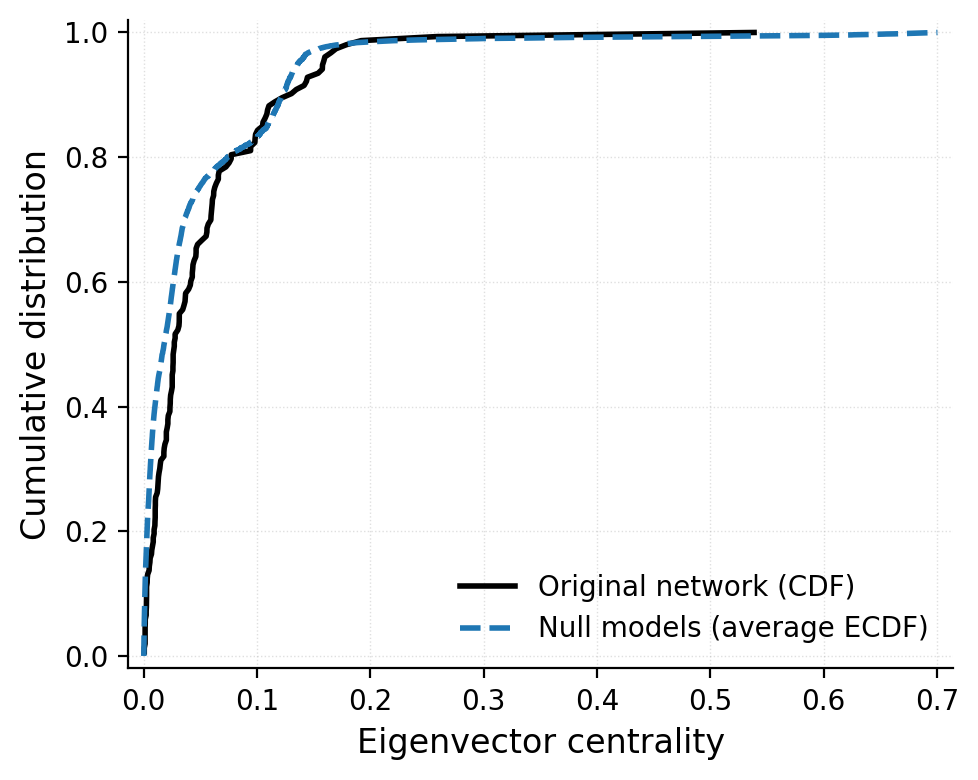

In [19]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, BA_graphs, statistic="eigenvector", ax=ax)
fig.tight_layout()

In [20]:
statistics = ["degree", "closeness", "eigenvector"]

for stat in statistics:
    ks_stat, p_val = ks_test_distribution(G, BA_graphs, stat)
    print(f"{stat}: KS statistic = {ks_stat:.4f}, p-value = {p_val:.4g}")

degree: KS statistic = 0.3129, p-value = 1.009e-13
closeness: KS statistic = 1.0000, p-value = 0
eigenvector: KS statistic = 0.1990, p-value = 9.422e-06


**(i)** The results show that although the BA model can reproduce the overall degree distribution shape of the original network to some extent, the KS statistic (0.3129, p≈10⁻¹³) still shows significant differences between the degree distributions, indicating that the edge formation mechanism of the real supply chain network is not solely dominated by the scaling law of "the rich get richer." More importantly, the difference in closeness centrality is extremely large (KS=1.0, p=0), and the node distance structure of the original network is completely inconsistent with the BA network. This indicates that the real EV supply chain has a stronger hierarchical structure, bottleneck paths, or regional communities, making the overall network distance much shorter or longer than the value predicted by BA. Compared with degree distribution and closeness centrality, the difference in eigenvector centrality between the original network and BA null models is significantly smaller. This suggests that although the overall distance structure and edge formation logic of the real EV supply chain network deviate from the BA model, the characteristic of "centrality being mutually reinforced by central nodes" still appears in a similar way in both networks.

In [27]:
def random_rewire_target(G, n_steps=100, p_same_indegree=0.8, seed=None):
    """
    Generate a random null model based on a given directed graph G.
    The operation is: randomly select an edge (u, v) and move its target from v to new_v.
    - Select a node new_v with the same in-degree as v with probability p_same_indegree.
    - Select any node new_v with probability (1 - p_same_indegree).
    Only the target is changed, so the out-degree remains unchanged.
    
    Parameters
    ----------
    G : nx.DiGraph
    The original directed graph (not modified, but copied internally).
    
    n_steps : int
    The number of reconnection operations.
    
    p_same_indegree : float
    The probability of selecting a node with the same in-degree.
    
    seed : int or None
    A random seed for easy reproduction.
    
    Returns
    -------
    H : nx.DiGraph
    The reconnected random directed graph (null model).
    """
    if seed is not None:
        random.seed(seed)
        
    H = G.copy()
    nodes = list(H.nodes())

    for _ in range(n_steps):
        if H.number_of_edges() == 0:
            break
        u, v = random.choice(list(H.edges()))

        indeg = dict(H.in_degree())
        use_same_indegree = random.random() < p_same_indegree

        if use_same_indegree:
            target_indeg = indeg[v]
            candidates = [
                x for x in nodes
                if x != u and x != v
                and indeg[x] == target_indeg
                and not H.has_edge(u, x)
            ]
            if not candidates:
                use_same_indegree = False

        if not use_same_indegree:
            candidates = [
                x for x in nodes
                if x != u and x != v
                and not H.has_edge(u, x)
            ]
        if not candidates:
            continue

        new_v = random.choice(candidates)
        H.remove_edge(u, v)
        H.add_edge(u, new_v)

    return H

In [28]:
def generate_RT_null_graphs(G, num_null=200):
    null_graphs = []
    n = len(G.nodes())
    for i in range(num_null):
        G_simple = random_rewire_target(G, n_steps=100, p_same_indegree=0.8, seed=i)
        null_graphs.append(G_simple)
    return null_graphs
RT_graphs = generate_RT_null_graphs(G)


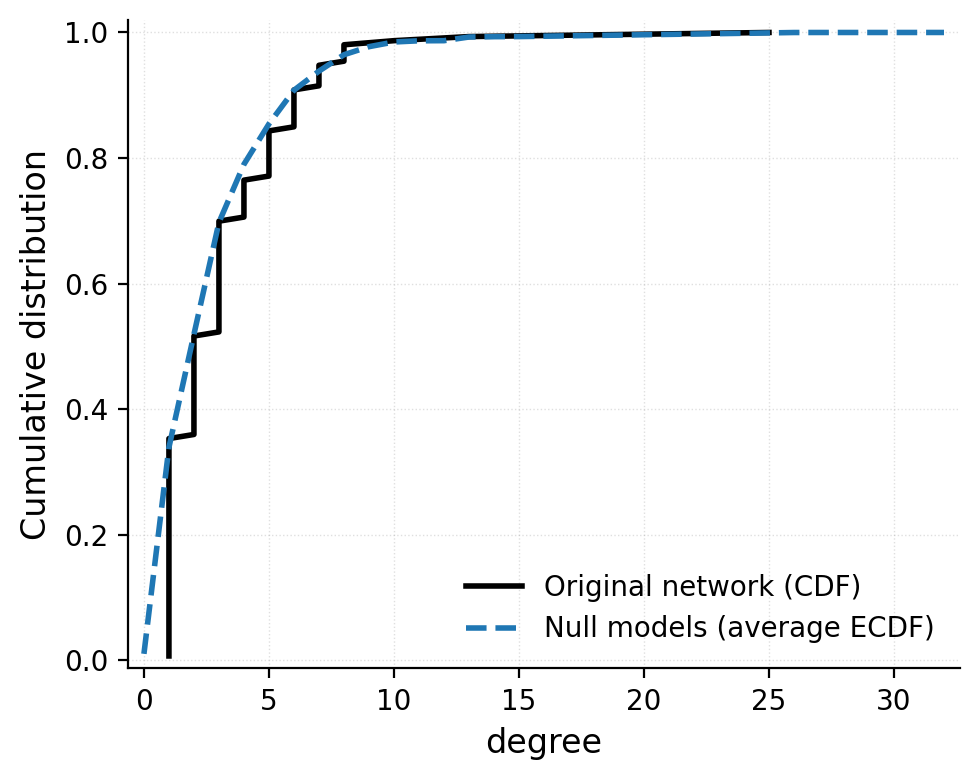

In [29]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, RT_graphs, statistic="degree", ax=ax)
fig.tight_layout()

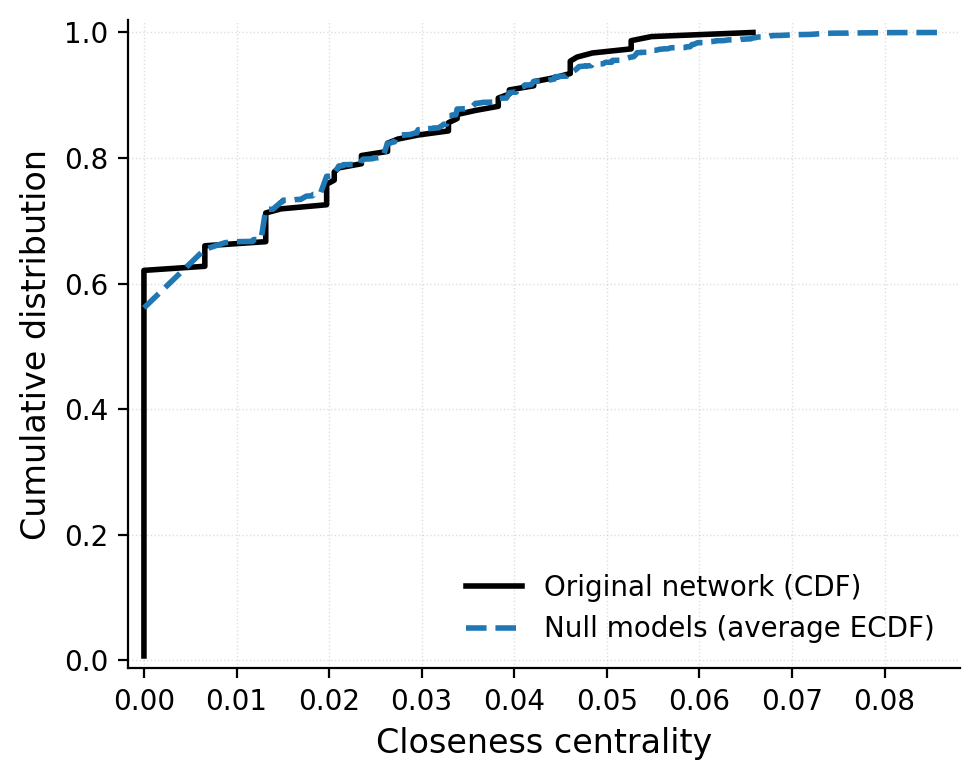

In [30]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, RT_graphs, statistic="closeness", ax=ax)
fig.tight_layout()

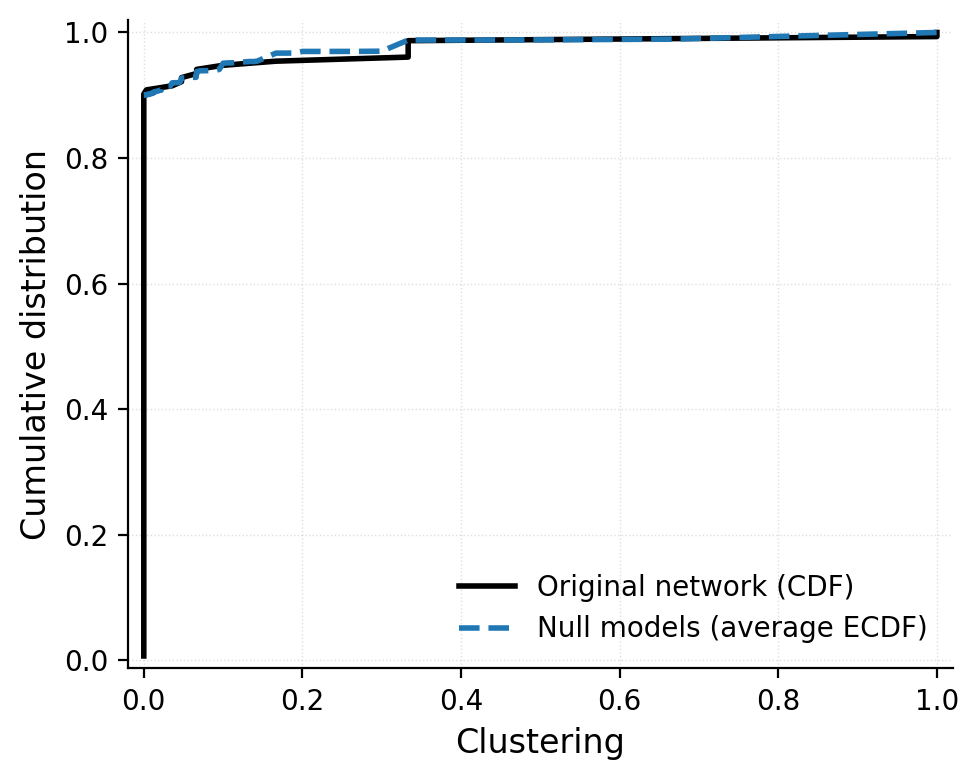

In [31]:
fig, ax = plt.subplots(figsize=(5,4), dpi=200)
plot_G_vs_null_cdf(G, RT_graphs, statistic="Clustering", ax=ax)
fig.tight_layout()

In [32]:
statistics = ["degree", "closeness", "Clustering"]

for stat in statistics:
    ks_stat, p_val = ks_test_distribution(G, RT_graphs, stat)
    print(f"{stat}: KS statistic = {ks_stat:.4f}, p-value = {p_val:.4g}")

degree: KS statistic = 0.0252, p-value = 0.9999
closeness: KS statistic = 0.0598, p-value = 0.6259
Clustering: KS statistic = 0.0159, p-value = 1


**(ii)**
Because this null model strictly maintains the out-degree of each node during rewiring and moves an edge to a node with the same in-degree with a probability of 0.8, the overall degree structure is almost completely preserved, making the degree distribution almost identical to the original network. Meanwhile, since rewiring only changes the target node of the edge, the large-scale reachability structure (closeness) of the network is somewhat perturbed, but the strong constraints of the degree structure still make its distribution quite close to the original network, indicating that the model only slightly alters the distance characteristics. On the other hand, clustering is most significantly affected by local structure, but because the rewiring process still strongly preserves the degree-driven connection pattern, the clustering distribution is also almost completely identical to the real network. Overall, this shows that this rule generates a weakly randomized null model that highly preserves the degree and local structural features of the real network. It changes the path structure but only within a limited range, resulting in a moderate shift in closeness, while degree and clustering remain almost unchanged.